<a href="https://colab.research.google.com/github/gtzan/mir_book/blob/master/ch1_sinusoidworld/Explaining_the_DFT_a_music_perspective_part5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A music and sound exposition of the Discrete Fourier Transform - Part 5

The Discrete Fourier Transform (DFT) is fundamental for any type of music and sound processing using computers. The goal of this notebook is to develop high-level intuition behind the concepts that underlie the DFT and understand how this transformation is used by various algorithms for audio analysis and synthesis. The intended audience is anyone with some knowledge of high school math that is interested in the topic. This is not a detailed mathematical digital signal processing (DSP) exposition. At the end of the notebook a variety of resources for better understanding the DFT and audio processing are provided for further digging.

There are many great resources for understanding the DFT including textbooks, tutorial articles, and videos some of which are listed at the end of this exposition. This material reflects my own personal way of teaching the DFT that has evolved over twenty years of experience with striving to explain the underlying concepts to students from diverse academic backgrounds and disciplines with a focus on how it connects to music information retrieval.

In **Part 1** we looked at how we can create complex sounds by combining sinudoids of different frequencies and amplitudes that change over time (additive synthesis) such as the sound of a bell or even the infamous THX sound. We also can create plausible and recognizable music melodies and tunes that are similar to the chip tunes made by the early game machines and computer sound cards.

In **Part 2** we started looked at the inverse problem of analysis. Given an array of audio samples that correspond to a complex sound or a simple melody we would like to find what are the frequencies and amplitudes of each sinusoidal component. We started by the simple problem of amplitude estimation of a single sinusoid and looked at peak and RMS amplitude. These methods were not very accurate in the presence of interference so we looked a estimating the amplitude through a dot-product (correlation) with **probe/basis** sinusoid with unit amplitude and frequency equal to the frequency we were looking for. This approach was shown to be very robust to the presence of interference but does require knowledge of the frequency you are training to estimate the amplitude for as well as phase alignment between the probe/basis and the target sinusoid.


In **Part 3** we looked at how we can deal with time and phase. For time we can perform **short-time processing** in which we process the audio samples in small chunks that are long enough to contain a few cycles of the sinusoids we are intrested in but short enough to allow us to estimate amplitudes that change over time.

To estimate the amplitude accurately when the **probe/basis** signal and the target sinusoid are not aligned in time we can calculate multiple amplitude estimate for different time shifts and select the maximum amplitude estimate as our amplitude estimate. This approach is called **cross-correlation** and is a fundamental digital signal processing operation with direct equivalents in mamallian auditory systems. It is a computationally costly operation as multiple dot-products need to be computed and the accuracy of the estimation depends on how many time shits are considered. It can also work for other waveforms than sinusoids. However, if we are dealing with sinusoids there is a much more efficient, clever way to estimate the amplitude.

If we are looking for the amplitude of a sinusoidal signal that is part of a complex signal and we know it's frequency we can take use inner-products of array corresponding to the complex signal that contains our "burried" sinusoid with two basis arrays (or probes) one containing a sampled sine signal of the known frequency and one containing a sampled cosine signal of the known frequency. The resulting two ampltitude estimates can be combined to return an estimate of the mangitude of the sinusoid as well as an estimate of the phase. Each of these sinusoids can be considered a "probe" or "basis" and is a building block that can take as input a complex input signal consisting of multiple sinusoidal signals and potentially other interferring sounds and estimate reliably the amplitude and the phase of of a sinusoid with a particular frequency of interest.

In this **Part 4** we looked at how this basis/probe pair of a unit amplitude sine array of samples and a unit amplitude cosine array of samples form an amplitude and phase estimator for a particular frequency. By creating a linearly-spaced grid of frequencies we can create a transform that can change the representation of our signal from the time-domain to the frequency domain. The frequency domain (or spectrum) specifies how we can re-synthesize/re-construct our original time-domain signal by appropriately combining sinusoids with the estimated dot-product amplitudes with the two basis/probe signals from each frequency. These can be converted to actual amplitude and phase. To re-synthesize the sinusoidal components from the frequency domain we do not need to recompute samples of the sine and cosine function but can simply weigh each probe/basis appropriately and add them together. We called this the Discrete Probe Transform and showed that it can perform **perfect reconstruction** i.e we can get back our original input signal from the spectrum (frequency domain) without any loss of information. The Discrete Probe transform is essentially the Discrete Fourier Transform (DFT). In this part we formalize the DFT and start introducing some cool mathematical notation. The pair of basis/probes amplitude/phase estimator for a specific frequency is the basic building block and the key to understanding the DFT.  



# The Discrete Fourier Transform  


We are finally ready to explore the Discrete Fourier Transform which is a fundamental algorithm in Digital Signal Processing.

















First let's look at the typical mathematical notation:

\begin{equation}
X_k = <x, e^{jtk2\pi /N}> = \sum_{t=0}^{N-1} x_t e^{-j t k 2 \pi/N}  
\end{equation}

We start with a finite, length-N segment of a digital signal $x_0, x_1, \dots, x_{N-1}$. We define the inner product as:
\begin{equation}
<x,y> = \sum_{t=0}^{N-1} x_t y_t^*
\end{equation}
and the corresponding basis are $N$ frequency cosine and sine probe pairs
 equally spaced in the desired rage from zero to the sampling frequency:
\begin{equation}
{e^{jtk2\pi/N}} = {cos(tk2\pi/N) + j sin(tk2\pi/N})\;\;\; \text{for} \;\; 0 \leq k \leq N-1
\end{equation}

This is a typical description you can find in a Digital Signal Processing textbook or Wikipedia and contains a bunch of math notation we have not covered but as we will see essentially we are using $N$ "basis/probes" to estimate the corresponding amplitudes and phases of the sinusoids present in a sound mixture based on all the ideas we have covered so far in Part 1, 2, 3 and 4.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
%matplotlib inline
import logging
import matplotlib.pyplot as plt

# Silence the font manager logging system
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# xkcd style plots and suppress font warnings
plt.xkcd()

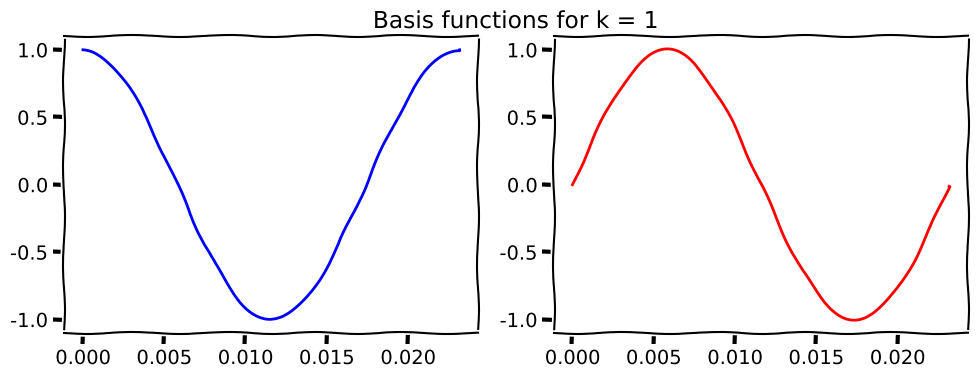

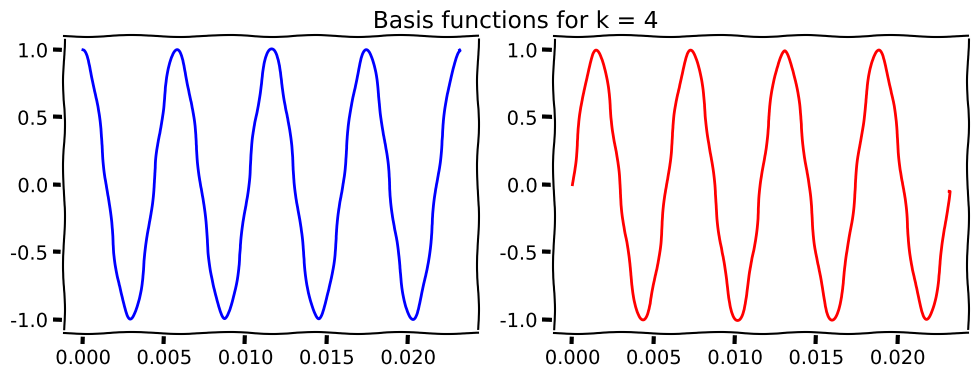

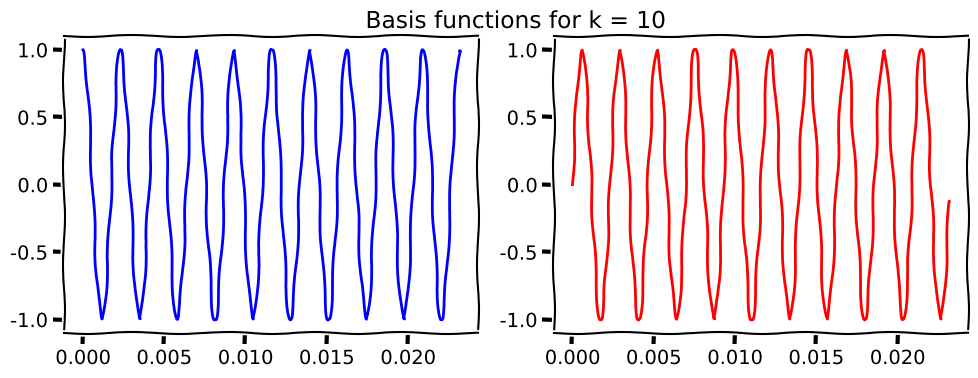

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
%matplotlib inline
import logging
import matplotlib.pyplot as plt

# Silence the font manager logging system
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# xkcd style plots and suppress font warnings
plt.xkcd()


def plot_basis(t, x_cos, x_sin,k):
    # plot them
    plt.figure(figsize=(10,4))
    plt.axis('off')

    plt.title('Basis functions for k = ' + str(k))
    plt.subplot(121)
    plt.plot(t, x_cos, lw=2, color='blue')
    plt.subplot(122)
    plt.plot(t, x_sin, lw=2, color='red')
    plt.tight_layout()
    plt.show()

srate = 22050
N = 512
t = np.arange(0,N)
ts = np.arange(0,N)/srate

for k in [1,4,10]:
  # basis functions
  x_cos = np.cos(k*t*2*np.pi/N)
  x_sin = np.sin(k*t*2*np.pi/N)
  plot_basis(ts, x_cos, x_sin,k)


\begin{equation}
X_k = <x, e^{jtk2\pi /N}> = \sum_{t=0}^{N-1} x_t e^{-j t k 2 \pi/N}  = \sum_{t=0}^{N-1} x_t cos(tk2\pi/N) + \sum_{t=0}^{N-1} x_t  j sin(tk2\pi/N)
\end{equation}

Looking at the equation above you can see that for a specific $k$ the complex spectrum value $X_k$ can be computed by taking two inner products of the input array $x_t$ with the cosine array and sine array of the corresponding basis/probe for frequency $k$.

Let's consider as input a cosine signal of the same frequency as a particular pair of basis functions let's say with $k=4$ and look at the signal resulting from the point-wise multiplication of the input with the cosine part and the sine part. As you can see the point-wise multiplication with the cosine part results in a signal that is centered above zero and therefore the inner product is positive (the value is shown with the straight black line in the plot). The point-wise multiplication with the sine part results in a signal that is centered at zero and therefore the inner product is zero (the value is shown with the straight black line in the plot). Recall from before when we examined using the inner product with a sinusoid of known frequency to estimate amplitude that the estimated amplitude is simply twice the inner product.

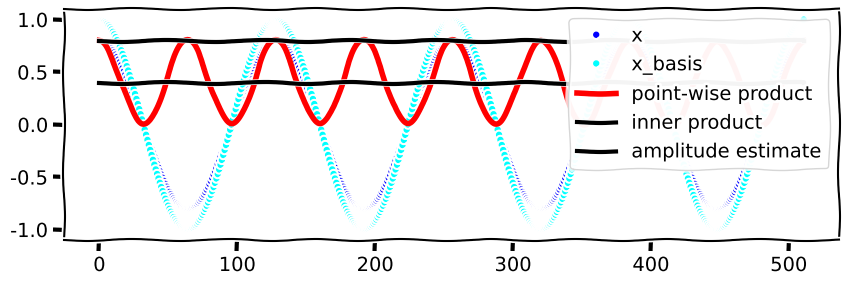

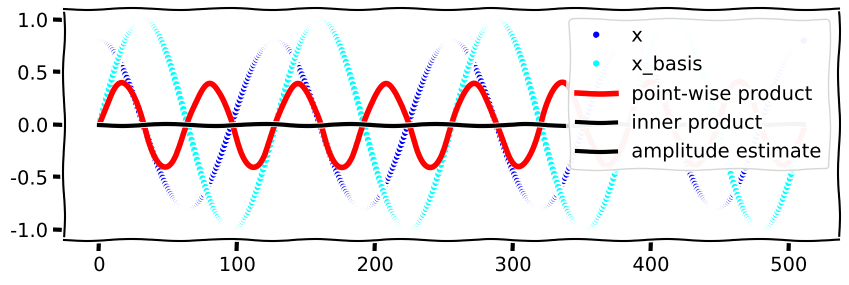

In [ ]:
def plot_product(t,x1,x2):
    prod = np.multiply(x1,x2)
    inner_prod = np.sum(prod) / len(prod)
    plt.figure(figsize=(10,3))
    plt.axis('on')

    plt.plot(t, x1,'.', lw=3, color='blue')
    plt.plot(t, x2,'.', lw=3, color='cyan')
    plt.plot(t, np.multiply(x1,x2), lw=4, color='red')
    ip_line = np.empty(len(prod))
    ip_line.fill(inner_prod)
    plt.plot(t, ip_line, lw=3, color='black')
    plt.plot(t, ip_line*2, lw=3, color='black')
    plt.legend(('x', 'x_basis', 'point-wise product', 'inner product', 'amplitude estimate'), loc='upper right')


k=4
a = 0.8
x = a * np.cos(k*t*2*np.pi/N)
x_cos = np.cos(k*t*2*np.pi/N)
x_sin = np.sin(k*t*2*np.pi/N)
plot_product(t,x,x_cos)
plot_product(t,x,x_sin)

Symmetrically, when the input is a sine wave the inner product with the cosine part of the basis is zero and the inner product with the sine part of the basis is positive.

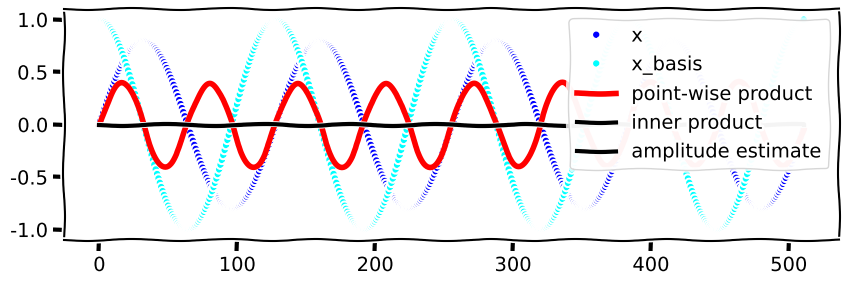

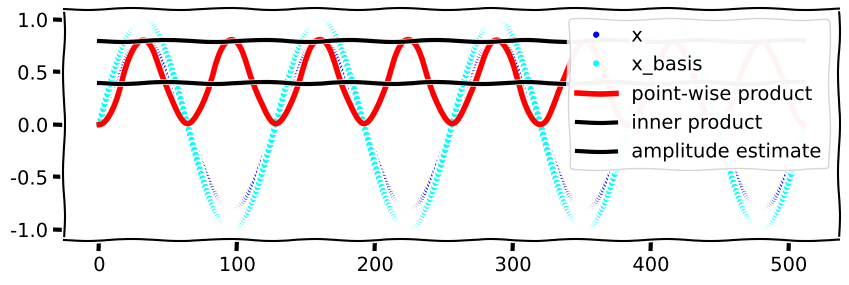

In [ ]:

x = a * np.sin(k*t*2*np.pi/N)
plot_product(t,x,x_cos)
plot_product(t,x,x_sin)


Now let's consider the case of using as input a sinusoidal signal of different frequency let's say corresponding to k=10. As you can observe in this case the inner products with both the real and imaginary part of the basis functions are zero.

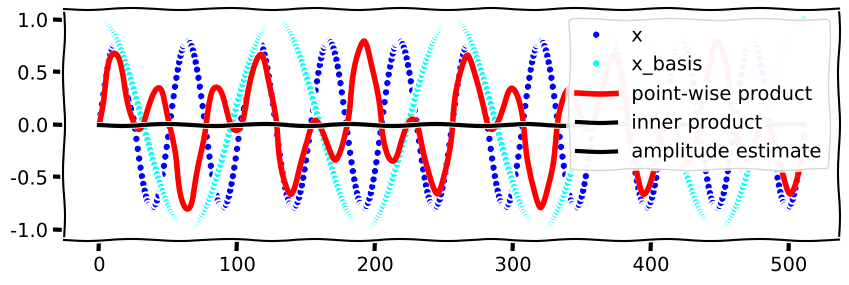

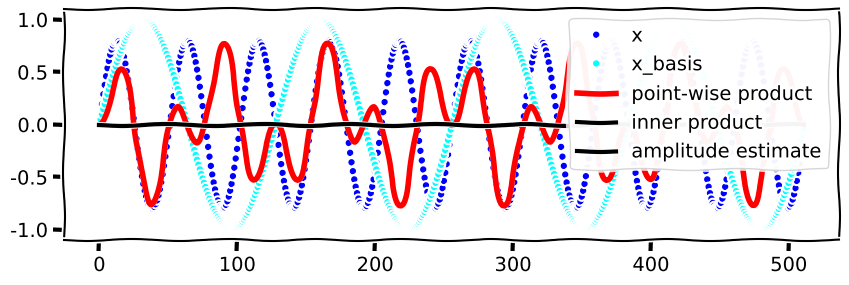

In [ ]:
k=10
x = a * np.sin(k*t*2*np.pi/N)
plot_product(t,x,x_cos)
plot_product(t,x,x_sin)

Now consider an input that is a mixure of two sinsoids. Notice that we are still able to correctly estimate the amplitude of the mixture component that corresponds to the basis function we are using.

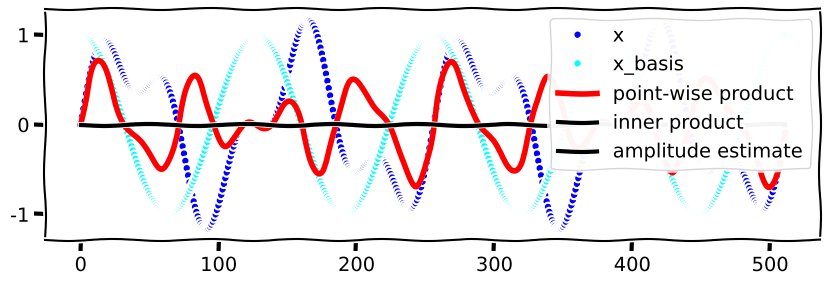

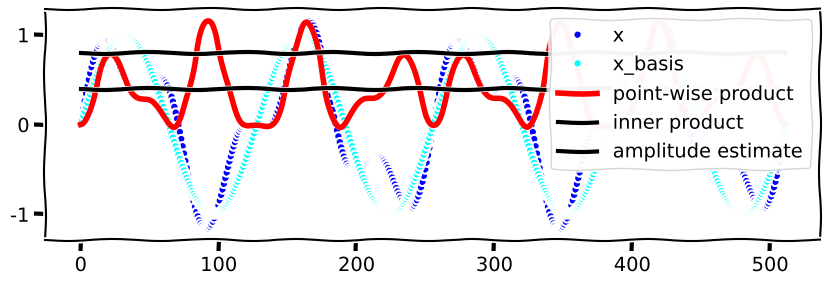

In [ ]:
k=4
a1 = 0.8
x1 = a1 * np.sin(k*t*2*np.pi/N)
a2 = 0.4
k = 10
x2 = a2 * np.sin(k*t*2*np.pi/N)
x = x1+x2
plot_product(t,x,x_cos)
plot_product(t,x,x_sin)

Finally lets look at computing the Discrete Fourier Transform directly from the equation and viewing the magnitude spectrum for the mixture signal we examined above. If you paid attention you will notice that there is a $j$ in the definition of the Discrete Fourier Transform. This is not a typo. There is also a superscript star in the definition of the inner product that we have also not explained and there is the notation using the exponential function. To make sense of this notation we will need to introduce the concept of **complex numbers** which we will do in the next part of this exposition. For now we will just provide one little hint: the amplitude estimate computed via the inner product with the cosine basis function is what we call the **real** part of a **complex number** and the amplitude estimate computed via the inner product with the sine basis function is what is called the **imaginary** part of a **complex number**. Even though you can understand and use the DFT without getting into **complex numbers** I strongly encourage you to read the next part and get a sense of how they work. It is a beautiful mathematical notation concept worth exploring and to some extent easier than what students typically think.

The code below is written so that the connection to measuring amplitude and phases using inner products with the cosine and sine parts of each basis element is emphasized and the code does not utilize the complex number type. Notice the normalization by $2/N$ so that the mangitude spectrum shows the estimated amplitudes of the input signal. It can easily be written in any programming language that supports arrays, loops, computing sine and cosine functions, and additions/multiplications.

Notice that in the code below we compute the magntiude and phase spectrum.
You can see there is a peak at $100$ but there is also one of the same height at $412$. When using the standard definition of the **Discrete Fourier Transform** the speectrum is "mirrored" at $0$. We will explain the reasoning behind this in the part 7 but for now we can see the peak corresponding to the input with the right amplitude.


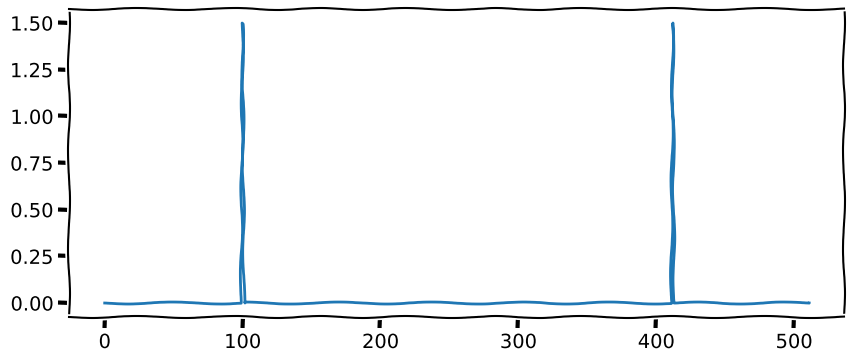

In [ ]:
def pedagogical_dft(x, N):
    X_cos = np.zeros(N)       # array holding the cosine/real parts of the spectrum
    X_sin = np.zeros(N)       # array holding the sine/imaginary values of the spectrum
    for k in np.arange(0,N):
        for t in np.arange(0,N):
            X_cos[k] += x[t] * np.cos(t * k * 2 * np.pi / N)   # inner product with cosine/real basis k
            X_sin[k] += x[t] * np.sin(t * k * 2 * np.pi / N)   # inner product with sine/imaginary basis k
    return (X_cos, X_sin)

def plot_mag_spectrum(Xmag):
    plt.figure(figsize=(10,4))
    n = np.arange(0,len(Xmag))
    plt.plot(n,Xmag)

N = 512
n = np.arange(0,N)

# Single sinusoid
k=100
x1 = 1.5 * np.sin(k*n*2*np.pi/N)

(X_cos, X_sin) = pedagogical_dft(x1, N)
Xmag = 2 * np.sqrt(X_cos * X_cos + X_sin * X_sin) /N
plot_mag_spectrum(Xmag)

Now let's look at a mixture of three sinusoids with different frequencies (all aligned with the linearly-spaced freqencies of analysis. You can notice a small change that I have used X_re instead of X_cos and X_im instead of X_sin in how I name the spectrum values to start thinking in terms of complex numbers.
As you can see in the plot, we get three nice peaks with the corresponding amplitudes mirrored at zero.

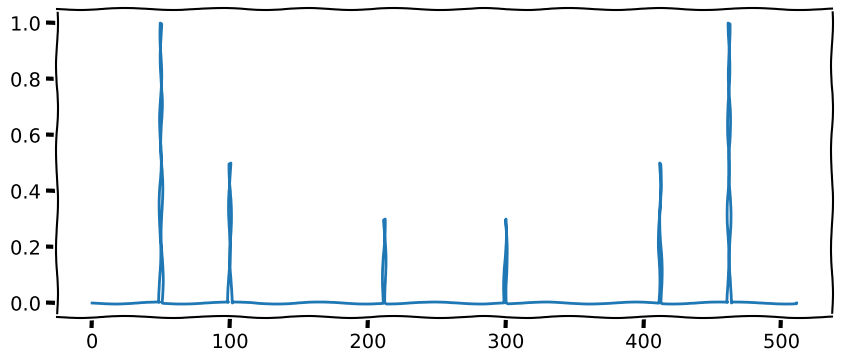

In [ ]:
# Mixture sinusoid input
x2 = np.sin(50*n*2*np.pi/N) + 0.5 * np.sin(100 * n * 2 * np.pi/N) + 0.3 * np.sin(300 * n * 2 * np.pi/N)

(X_re, X_im) = pedagogical_dft(x2, N)
Xmag = 2 * np.sqrt(X_re * X_re + X_im * X_im) / N
plot_mag_spectrum(Xmag)


The Discrete Fourier Transform as described above requires $N$ computations of inner-products of the input with the two cosine and sine arrays corresponding to the $N$ different frequencies under consideration. Each of the inner products requires $N$ multiplications. Therefore for this direct evaluation the total number of operations is what is called in Computer Science $O(N^2)$.

In practice, most of the time we use a fast implementation of the **DFT** called not surprisingly the **Fast Fourier Transform** or **FFT**. It is based on a recursive subdivision in which the DFT of the even samples is computed and the DFT of the odd samples is computed and then the result is combined - this process is repeated recursively and the resulting algorithm has a complexity of $O(NlogN)$ which for typical array sizes in audio processing makes a significant difference. We will not describe in detail how this works as this is beyond the scope of this exposition and does not affect how one interprets and understands the DFT or FFT. You simply get much faster computation.
There is an important caveat: for the FFT to be applied your input array needs to have a size that is a power of $2$. This is why it is very common in audio processing to use arrays of samples that are powers of $2$ such as 32, 64, 128, 256, 512, 1024, 2048, and 4096.

Let's check that the output of the **FFT** for the example above is identical to what we got with the direct evaluation pedagogical implementation of the **DFT**.



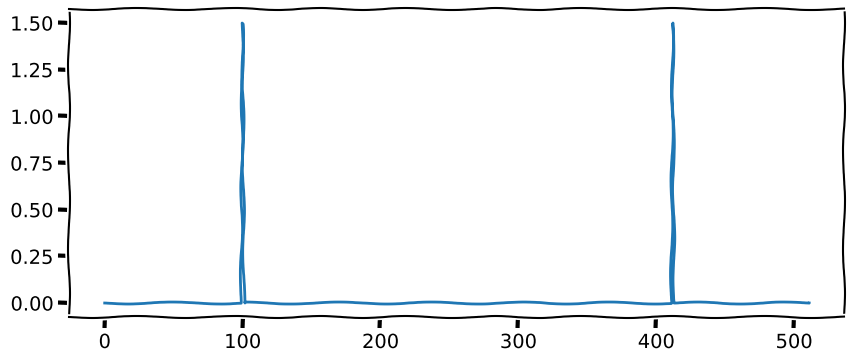

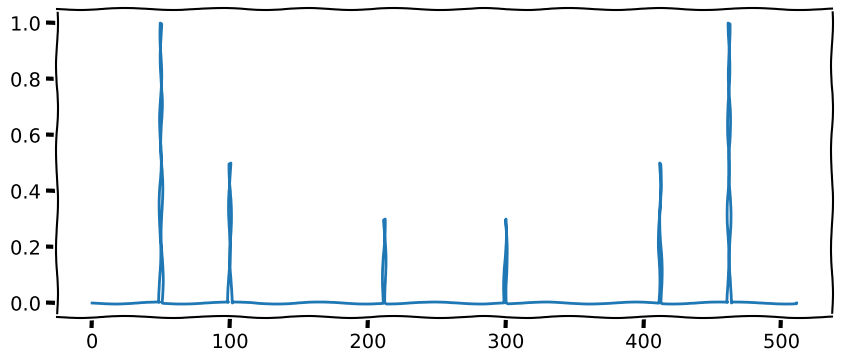

In [ ]:
X = np.fft.fft(x1)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)

X = np.fft.fft(x2)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)

Let's do a time measurement of the direct evaluation **DFT** and then compare it with the equivalent processing with the **FFT**. The direct evaluation **DFT** takes about 15seconds when I run this notebook.

In [ ]:
%%time
import numpy as np

def pedagogical_dft(x, N):
    X_re = np.zeros(N)       # array holding the real parts of the spectrum
    X_im = np.zeros(N)       # array holding the imaginary values of the spectrum
    for k in np.arange(0,N):

        for t in np.arange(0,N):
            X_re[k] += x[t] * np.cos(t * k * 2 * np.pi / N)   # inner product with real basis k
            X_im[k] += x[t] * np.sin(t * k * 2 * np.pi / N)   # inner product with imaginary basis k
    return (X_re, X_im)

def test():
    x = np.zeros(512)
    for i in range(5):
      pedagogical_dft(x,512)

test()

CPU times: user 13.3 s, sys: 10.9 ms, total: 13.3 s
Wall time: 13.8 s


The **Fast Fourier Transform** equivalent takes 12 milliseconds.

In [ ]:
%%time
import numpy as np

def test():
    for i in range(5):
      x = np.zeros(512)
      np.fft.fft(x)
test()

CPU times: user 1.24 ms, sys: 0 ns, total: 1.24 ms
Wall time: 1.01 ms


In the next part we will look at some cool audio applications of what is called spectral processing that will help further solidify your understanding of the Discrete Fourier Transform.
